# KNN
Knn is a supervised algorithm and it is the simplest model in ml. It can be used for both classification and regression problems. It is a non parametric algorithm.

#### Import the libs

In [123]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

#### Load the dataset

In [124]:
data = pd.read_csv("breast_cancer.csv")
data.head()

,1000025,5,1,1.1,1.2,2,1.3,3,1.4,1.5,2.1
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2
3,1017023,4,1,1,3,2,1,3,1,1,2
4,1017122,8,10,10,8,7,10,9,7,1,4


In [125]:
col_names = ['Id', 'Clump_thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 
             'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']

data.columns = col_names

#### Explore the dataset

In [126]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Id                           698 non-null    int64 
 1   Clump_thickness              698 non-null    int64 
 2   Uniformity_Cell_Size         698 non-null    int64 
 3   Uniformity_Cell_Shape        698 non-null    int64 
 4   Marginal_Adhesion            698 non-null    int64 
 5   Single_Epithelial_Cell_Size  698 non-null    int64 
 6   Bare_Nuclei                  698 non-null    object
 7   Bland_Chromatin              698 non-null    int64 
 8   Normal_Nucleoli              698 non-null    int64 
 9   Mitoses                      698 non-null    int64 
 10  Class                        698 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


In [127]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,698.0,1.071807e+06,617532.274029,61634.0,870258.25,1171710.0,1238354.0,13454352.0
Clump_thickness,698.0,4.416905e+00,2.817673,1.0,2.00,4.0,6.0,10.0
Uniformity_Cell_Size,698.0,3.137536e+00,3.052575,1.0,1.00,1.0,5.0,10.0
Uniformity_Cell_Shape,698.0,3.210602e+00,2.972867,1.0,1.00,1.0,5.0,10.0
Marginal_Adhesion,698.0,2.809456e+00,2.856606,1.0,1.00,1.0,4.0,10.0
Single_Epithelial_Cell_Size,698.0,3.217765e+00,2.215408,1.0,2.00,2.0,4.0,10.0
Bland_Chromatin,698.0,3.438395e+00,2.440056,1.0,2.00,3.0,5.0,10.0
Normal_Nucleoli,698.0,2.869628e+00,3.055004,1.0,1.00,1.0,4.0,10.0
Mitoses,698.0,1.590258e+00,1.716162,1.0,1.00,1.0,1.0,10.0
Class,698.0,2.690544e+00,0.951596,2.0,2.00,2.0,4.0,4.0


In [128]:
data.drop(columns=["Id"],axis = -1,inplace=True)

In [129]:
data.head()

,Clump_thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,4,4,5,7,10,3,2,1,2
1,3,1,1,1,2,2,3,1,1,2
2,6,8,8,1,3,4,3,7,1,2
3,4,1,1,3,2,1,3,1,1,2
4,8,10,10,8,7,10,9,7,1,4


In [130]:
for var in data.columns:
    print(data[var].value_counts())

Clump_thickness
1     145
5     129
3     108
4      80
10     69
2      50
8      46
6      34
7      23
9      14
Name: count, dtype: int64
Uniformity_Cell_Size
1     383
10     67
3      52
2      45
4      40
5      30
8      29
6      27
7      19
9       6
Name: count, dtype: int64
Uniformity_Cell_Shape
1     352
2      59
10     58
3      56
4      44
5      34
7      30
6      30
8      28
9       7
Name: count, dtype: int64
Marginal_Adhesion
1     406
3      58
2      58
10     55
4      33
8      25
5      23
6      22
7      13
9       5
Name: count, dtype: int64
Single_Epithelial_Cell_Size
2     385
3      72
4      48
1      47
6      41
5      39
10     31
8      21
7      12
9       2
Name: count, dtype: int64
Bare_Nuclei
1     401
10    132
2      30
5      30
3      28
8      21
4      19
?      16
9       9
7       8
6       4
Name: count, dtype: int64
Bland_Chromatin
2     166
3     164
1     152
7      73
4      40
5      34
8      28
10     20
9      11
6      10
N

#### Convert the datatype of the Bare_nuclei to integer

In [131]:
data["Bare_Nuclei"] = pd.to_numeric(data["Bare_Nuclei"],errors="coerce")

In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              698 non-null    int64  
 1   Uniformity_Cell_Size         698 non-null    int64  
 2   Uniformity_Cell_Shape        698 non-null    int64  
 3   Marginal_Adhesion            698 non-null    int64  
 4   Single_Epithelial_Cell_Size  698 non-null    int64  
 5   Bare_Nuclei                  682 non-null    float64
 6   Bland_Chromatin              698 non-null    int64  
 7   Normal_Nucleoli              698 non-null    int64  
 8   Mitoses                      698 non-null    int64  
 9   Class                        698 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


#### Check the null values in the dataset

In [133]:
data.isnull().sum()

Clump_thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

In [134]:
data.isna().sum()

Clump_thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

In [135]:
data["Bare_Nuclei"].value_counts()

Bare_Nuclei
1.0     401
10.0    132
2.0      30
5.0      30
3.0      28
8.0      21
4.0      19
9.0       9
7.0       8
6.0       4
Name: count, dtype: int64

In [136]:
data["Bare_Nuclei"].unique()

array([10.,  2.,  4.,  1.,  3.,  9.,  7., nan,  5.,  8.,  6.])

Check the Class variable

In [137]:
data["Class"].value_counts(normalize = True)

Class
2    0.654728
4    0.345272
Name: proportion, dtype: float64

### Data Visualization

array([[<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>],
       [<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>],
       [<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>],
       [<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>],
       [<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>]],
      dtype=object)

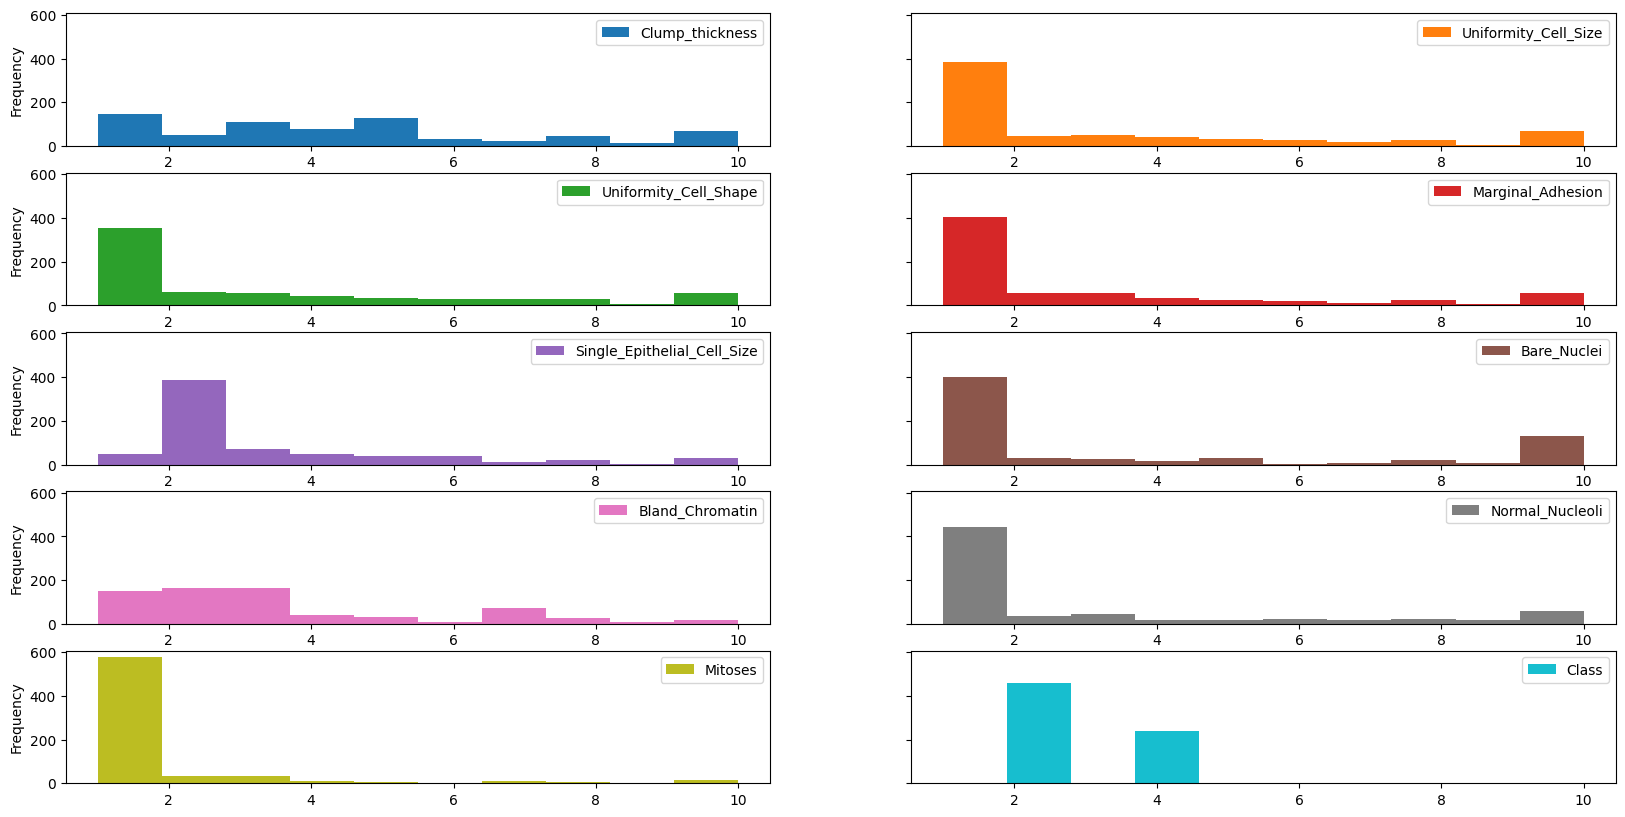

In [138]:
data.plot(kind = "hist",bins = 10,subplots=True,layout=(5,2),sharex=False,sharey=True,figsize=(20,10))

### Estimating Correlation coefficient

In [139]:
import seaborn as sns

<Axes: >

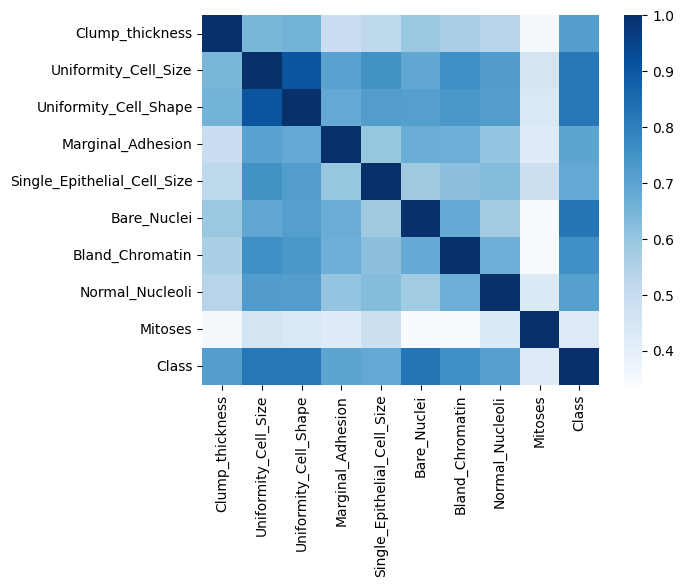

In [140]:
corr_matrix = data.corr()
sns.heatmap(corr_matrix,cmap=plt.cm.Blues)


### Determine the X and y values

In [142]:
col_median = data["Bare_Nuclei"].median()
col_median

np.float64(1.0)

In [ ]:
data["Barei_Nuclei"].fillna(col_median,inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_19884\2959994203.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Class"].fillna(col_median,inplace=True)


In [ ]:
X = data.drop(columns=["Class"])
y = data.Class
X,y

(     Clump_thickness  Uniformity_Cell_Size  Uniformity_Cell_Shape  \
 0                  5                     4                      4   
 1                  3                     1                      1   
 2                  6                     8                      8   
 3                  4                     1                      1   
 4                  8                    10                     10   
 ..               ...                   ...                    ...   
 693                3                     1                      1   
 694                2                     1                      1   
 695                5                    10                     10   
 696                4                     8                      6   
 697                4                     8                      8   
 
      Marginal_Adhesion  Single_Epithelial_Cell_Size  Bare_Nuclei  \
 0                    5                            7         10.0   
 1                  

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

In [146]:
X_train.fillna(col_median,inplace=True),X_test.fillna(col_median,inplace=True)

(None, None)

In [ ]:
X_train.head(),X_test.head()

(          0         1         2         3         4         5         6  \
 0 -0.499014 -0.686318 -0.741845 -0.627477 -0.533140 -0.416596  1.494165   
 1  1.968261 -0.019131  0.965868 -0.270564 -0.074047  0.416086  0.255931   
 2  1.968261  0.981650  0.282783  0.086350  3.139602  1.803890  2.319654   
 3  0.205922 -0.686318 -0.741845 -0.627477 -0.533140 -0.694157 -0.156813   
 4  0.205922 -0.686318 -0.741845 -0.627477 -0.533140 -0.694157 -0.569558   
 
           7         8  
 0 -0.600954 -0.322901  
 1  2.447523  0.258320  
 2  2.447523 -0.322901  
 3 -0.600954 -0.322901  
 4 -0.600954 -0.322901  ,
           0         1         2         3         4         5         6  \
 0  1.615793  1.982431  2.332039  0.086350  1.303231  1.803890  1.494165   
 1  0.558390 -0.686318 -0.741845 -0.627477 -0.533140 -0.694157 -0.156813   
 2 -0.146546 -0.686318 -0.741845 -0.627477 -0.533140 -0.694157 -0.982302   
 3 -1.203949 -0.352724 -0.400303 -0.627477 -0.533140 -0.694157 -0.569558   
 4 -0.49901

### Create the KNN model

In [147]:
Knn_classifier = KNeighborsClassifier(n_neighbors=3)
Knn_classifier.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Make predictionsn

In [148]:
y_pred = Knn_classifier.predict(X_test)
y_pred

array([4, 2, 2, 2, 2, 4, 2, 2, 2, 4, 2, 4, 4, 2, 2, 4, 2, 2, 4, 4, 4, 4,
       4, 2, 4, 2, 2, 4, 2, 4, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 4, 4, 4, 2,
       2, 2, 2, 4, 2, 4, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 4, 2, 4, 2, 2, 4,
       2, 4, 2, 2, 2, 4, 2, 2, 2, 2, 2, 4, 2, 4, 4, 2, 2, 4, 4, 4, 2, 2,
       2, 2, 2, 4, 2, 2, 4, 2, 2, 2, 4, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 4,
       4, 2, 2, 2, 2, 4, 2, 2, 4, 4, 4, 2, 2, 2, 2, 4, 2, 4, 4, 4, 4, 2,
       4, 4, 4, 4, 2, 2, 4, 4])

In [150]:
Knn_classifier.predict_proba(X_test)[:,0]

array([0.        , 1.        , 1.        , 1.        , 1.        ,
       0.        , 1.        , 1.        , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 1.        ,
       0.        , 1.        , 1.        , 0.33333333, 0.        ,
       0.        , 0.        , 0.        , 1.        , 0.        ,
       1.        , 1.        , 0.        , 1.        , 0.33333333,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.66666667, 0.        , 1.        , 1.        ,
       0.        , 0.        , 0.33333333, 1.        , 1.        ,
       1.        , 1.        , 0.        , 1.        , 0.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 0.33333333, 1.        , 1.        ,
       0.        , 1.        , 0.        , 1.        , 1.        ,
       0.33333333, 1.        , 0.        , 1.        , 1.        ,
       1.        , 0.33333333, 1.        , 1.        , 1.     

In [151]:
Knn_classifier.predict_proba(X_test)[:,1]

array([1.        , 0.        , 0.        , 0.        , 0.        ,
       1.        , 0.        , 0.        , 0.        , 1.        ,
       0.        , 1.        , 1.        , 0.        , 0.        ,
       1.        , 0.        , 0.        , 0.66666667, 1.        ,
       1.        , 1.        , 1.        , 0.        , 1.        ,
       0.        , 0.        , 1.        , 0.        , 0.66666667,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.33333333, 1.        , 0.        , 0.        ,
       1.        , 1.        , 0.66666667, 0.        , 0.        ,
       0.        , 0.        , 1.        , 0.        , 1.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.66666667, 0.        , 0.        ,
       1.        , 0.        , 1.        , 0.        , 0.        ,
       0.66666667, 0.        , 1.        , 0.        , 0.        ,
       0.        , 0.66666667, 0.        , 0.        , 0.     

### Evaluate the model

In [154]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy : ",accuracy)

Accuracy :  0.9785714285714285


Compare the Train and Test set

In [155]:
Train_score=Knn_classifier.score(X_train,y_train)
Test_score=Knn_classifier.score(X_test,y_test)
print("Train : ",Train_score)
print("Test : ",Test_score)

Train :  0.974910394265233
Test :  0.9785714285714285


### Recreate model by changing the number of neighbors

In [163]:
def recreate_Knn_model(X_train,X_test,y_train,y_test,neighbors):
    knn_classifier = KNeighborsClassifier(n_neighbors=neighbors,metric="manhattan")
    knn_classifier.fit(X_train,y_train)
    y_pred = knn_classifier.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    return accuracy

In [161]:
accuracies = []

In [174]:
for i in range(5,20):
    accuracy = recreate_Knn_model(X_train,X_test,y_train,y_test,neighbors=i)
    accuracies.append(accuracy)
    
accuracies

[0.9785714285714285,
 0.9714285714285714,
 0.9785714285714285,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9785714285714285,
 0.9714285714285714,
 0.9785714285714285,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9785714285714285,
 0.9714285714285714,
 0.9785714285714285,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9714285714285714,
 0.9785714285714285,
 0.9714285714285714,
 0.9785714285

In [175]:
from sklearn.metrics import confusion_matrix
confus = confusion_matrix(y_test,y_pred)
confus

array([[86,  3],
       [ 0, 51]])

In [177]:
acc =  recreate_Knn_model(X_train,X_test,y_train,y_test,7)
accuracy,acc

(0.9714285714285714, 0.9785714285714285)